In [1]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.stats import skew, kurtosis
import geopandas as gpd


In [2]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/05-outliers-processed/yellow_tripdata_2024-01.parquet")

# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)

1 files merged
(2568026, 25)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2568026 entries, 0 to 2568025
Data columns (total 25 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   vendor                   category      
 1   tpep_pickup_datetime     datetime64[us]
 2   tpep_dropoff_datetime    datetime64[us]
 3   passenger_count          Int64         
 4   ratecode                 object        
 5   payment_type             category      
 6   fare_amount              float64       
 7   extra                    float64       
 8   mta_tax                  float64       
 9   tip_amount               float64       
 10  tolls_amount             float64       
 11  improvement_surcharge    float64       
 12  total_amount             float64       
 13  congestion_surcharge     float64       
 14  Airport_fee              float64       
 15  pickup_borough           category      
 16  pickup_zone              category      
 17  pickup_service_zone      ca

In [4]:
# Location

# Taxi zone requiere técnicas de data enrichment. Importamos dataset de taxi_zone_lookup
taxi_zones = pd.read_csv(r"..\dataset\taxi_zone_lookup.csv")
zones = gpd.read_file(r"..\dataset\taxi_zones\taxi_zones.shp")


In [5]:
df.head(2)

,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,ratecode,payment_type,fare_amount,extra,mta_tax,tip_amount,...,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,pickup_hour,hour_bin,log_trip_distance,total_amount_calculated
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,Standard rate,Cash,17.70,1.00,0.50,0.00,...,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone,0,0-2,1.00,22.70
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,Standard rate,Credit card,10.00,3.50,0.50,3.75,...,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,0,0-2,1.03,21.25


In [6]:
MES = 1  # Enero
df = df[(df['tpep_pickup_datetime'].dt.month == MES) &
        (df['tpep_dropoff_datetime'].dt.month == MES) 
        ]

df = df[df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime']]

df = df[(df['fare_amount'] > 0) & (df['tip_amount'] >= 0)]
df_mh = df.copy() 

In [7]:
## Convierto fechas de pickup y dropoff a columnas separadas de día y hora

df_mh['pickup_day'] = df_mh['tpep_pickup_datetime'].dt.day
df_mh['pickup_hr'] = df_mh['tpep_pickup_datetime'].dt.hour
df_mh['weekday'] = df_mh['tpep_pickup_datetime'].dt.weekday # monday = 0, sunday = 6

df_mh['dropoff_day'] = df_mh['tpep_dropoff_datetime'].dt.day
df_mh['dropoff_hr'] = df_mh['tpep_dropoff_datetime'].dt.hour

df_mh['revenue'] = df_mh['fare_amount'] + df_mh['tip_amount']

df_mh.head(2)

,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,ratecode,payment_type,fare_amount,extra,mta_tax,tip_amount,...,pickup_hour,hour_bin,log_trip_distance,total_amount_calculated,pickup_day,pickup_hr,weekday,dropoff_day,dropoff_hr,revenue
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,Standard rate,Cash,17.70,1.00,0.50,0.00,...,0,0-2,1.00,22.70,1,0,0,1,1,17.70
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,Standard rate,Credit card,10.00,3.50,0.50,3.75,...,0,0-2,1.03,21.25,1,0,0,1,0,13.75


In [8]:
df_mh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2567535 entries, 0 to 2568024
Data columns (total 31 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   vendor                   category      
 1   tpep_pickup_datetime     datetime64[us]
 2   tpep_dropoff_datetime    datetime64[us]
 3   passenger_count          Int64         
 4   ratecode                 object        
 5   payment_type             category      
 6   fare_amount              float64       
 7   extra                    float64       
 8   mta_tax                  float64       
 9   tip_amount               float64       
 10  tolls_amount             float64       
 11  improvement_surcharge    float64       
 12  total_amount             float64       
 13  congestion_surcharge     float64       
 14  Airport_fee              float64       
 15  pickup_borough           category      
 16  pickup_zone              category      
 17  pickup_service_zone      categor

### Funciones

In [9]:

def mapa_heatmap_nyc(
    df,
    group_col="pickup_zone",
    agg="count",
    value_col=None,
    zones_path=r"..\dataset\taxi_zones\taxi_zones.shp",
    zones_key="zone",
    title=None,
    cmap="magma",
    log_scale=False,
    vmax_quantile=None,      # ej. 0.95 para capar en p95
    focus_borough=None       # ej. "Manhattan" si querés zoom
):
    """
    Mapa heatmap de NYC usando tus columnas (pickup_zone, pickup_borough, etc.)
    Con opciones de:
      - log_scale: escala logarítmica en la métrica
      - vmax_quantile: recortar escala en un percentil (p.ej. 0.95)
      - focus_borough: filtrar a un borough (usa columna 'borough' del shapefile)
    """
    zonas = gpd.read_file(zones_path)

    # Filtrar solo un borough si se pide
    if focus_borough is not None and "borough" in zonas.columns:
        zonas = zonas[zonas["borough"] == focus_borough]

    # Agregación
    if agg == "count":
        agg_df = (
            df.groupby(group_col)
              .size()
              .rename("valor")
              .reset_index()
        )
    elif agg == "mean":
        if value_col is None:
            raise ValueError("Para agg='mean' tenés que pasar value_col")
        agg_df = (
            df.groupby(group_col)[value_col]
              .mean()
              .rename("valor")
              .reset_index()
        )
    else:
        raise ValueError("agg debe ser 'count' o 'mean'")

    # Merge
    zonas_mapa = zonas.merge(
        agg_df,
        left_on=zones_key,
        right_on=group_col,
        how="left"
    )
    zonas_mapa["valor"] = zonas_mapa["valor"].fillna(0)

    # Transformaciones para el color
    vals = zonas_mapa["valor"].astype(float)

    if log_scale:
        vals_plot = np.log1p(vals)
    else:
        vals_plot = vals

    vmin = vals_plot.min()
    if vmax_quantile is not None:
        vmax = vals_plot.quantile(vmax_quantile)
    else:
        vmax = vals_plot.max()

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    zonas_mapa.plot(
        column=vals_plot,
        ax=ax,
        cmap=cmap,
        legend=True,
        vmin=vmin,
        vmax=vmax,
        edgecolor="black",
        linewidth=0.2
    )

    ax.set_axis_off()
    if title is None:
        title = f"Heatmap NYC – {group_col}"
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [10]:
def resumen_temporal(
        df,
        col_day,
        col_hour,
        col_weekday,
        etiqueta="pickup"
):
    """
    EDA temporal cuando ya tengo día, hora y día de la semana como columnas separadas.

    Parámetros:
    - col_day: nombre de la columna con el día del mes (int, 1–31)
    - col_hour: nombre de la columna con la hora (int, 0–23)
    - col_weekday: nombre de la columna con el día de la semana (0=Lun … 6=Dom)
    - etiqueta: string para títulos (ej: "pickup" o "dropoff")
    """

    print(f"\n===== Análisis temporal ({etiqueta}) =====")
    print(f"Total registros: {len(df)}")

    # Por si hubiera nulos (aunque sean int32)
    mask_valid = (
        df[col_day].notna() &
        df[col_hour].notna() &
        df[col_weekday].notna()
    )
    n_valid = mask_valid.sum()
    n_nulos = len(df) - n_valid

    print(f"No nulos (todas las columnas): {n_valid} | Registros con algún nulo: {n_nulos}")

    if n_valid == 0:
        print("No hay registros válidos para este análisis.")
        return
    

    dias_mes = df.loc[mask_valid, col_day].astype(int)
    horas = df.loc[mask_valid, col_hour].astype(int)
    dias_semana = df.loc[mask_valid, col_weekday].astype(int)

    # ---- Estadísticos básicos ----
    print(f"\nDía mínimo: {dias_mes.min()} | Día máximo: {dias_mes.max()}")
    print(f"Horas presentes: {sorted(horas.unique())[:10]}{' ...' if len(horas.unique())>10 else ''}")
    print(f"Días de semana presentes (0=Lun … 6=Dom): {sorted(dias_semana.unique())}")

    # ---- Gráficos ----

    # =============== G R Á F I C O S ==================
    fig, ax = plt.subplots(4, 1, figsize=(16, 20))

    # 1) Distribución por día del mes
    sns.countplot(x=dias_mes, ax=ax[0])
    ax[0].set_title(f"{etiqueta}: Distribución por día del mes")
    ax[0].set_xlabel("Día del mes (1–31)")
    ax[0].set_ylabel("Cantidad de viajes")

    # 2) Distribución por hora del día
    sns.countplot(x=horas, ax=ax[1])
    ax[1].set_title(f"{etiqueta}: Distribución por hora del día")
    ax[1].set_xlabel("Hora (0–23)")
    ax[1].set_ylabel("Cantidad de viajes")

    # 3) Distribución por día de la semana
    sns.countplot(x=dias_semana, ax=ax[2])
    ax[2].set_title(f"{etiqueta}: Distribución por día de la semana")
    ax[2].set_xlabel("Día (0=Lun … 6=Dom)")
    ax[2].set_ylabel("Cantidad de viajes")

    # 4) Heatmap hora × día de la semana
    cross = df.loc[mask_valid, [col_day, col_hour, col_weekday]].copy()
    cross.rename(
        columns={
            col_hour: "hora",
            col_weekday: "dia_sem"
        },
        inplace=True
    )

    tabla = cross.pivot_table(
        index="dia_sem",
        columns="hora",
        values=col_day,     # da igual, usamos count
        aggfunc="count"
    )

    sns.heatmap(tabla, cmap="YlOrRd", ax=ax[3])
    ax[3].set_title(f"{etiqueta}: Heatmap viajes por hora × día de la semana")
    ax[3].set_xlabel("Hora del día")
    ax[3].set_ylabel("Día de la semana (0=Lun … 6=Dom)")

    plt.tight_layout()
    plt.show()

    return {
        "n_total": len(df),
        "n_validos": int(n_valid),
        "n_nulos": int(n_nulos),
        "dias_presentes": sorted(dias_mes.unique()),
        "horas_presentes": sorted(horas.unique()),
        "dias_semana_presentes": sorted(dias_semana.unique())
    }

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

def analisis_revenue(
    df,
    zones_path=r"..\dataset\taxi_zones\taxi_zones.shp",
    borough_filter="Manhattan",
    revenue_col="revenue",
    p_cut=0.99
):
    """
    Hace:
      - Crea df[revenue_col] = fare_amount + tip_amount si no existe.
      - Filtra registros con fare_amount > 0 y tip_amount > 0.
      - Muestra histogramas (completo + recortado) de fare, tip y revenue,
        con línea de mediana.
      - Mapa choropleth de mediana de revenue por pickup_zone en borough_filter.
      - Heatmap de mediana de revenue por weekday × pickup_hr.
    """

    # ----------- 0) Preparación: revenue -----------
    if revenue_col not in df.columns:
        df[revenue_col] = df["fare_amount"] + df["tip_amount"]


    print(f"Usando columna de revenue: '{revenue_col}'")
    print(f"Total registros originales: {len(df):,}")
    print(f"Registros con fare_amount > 0, tip_amount > 0 y revenue > 0: {len(df):,}")

    # ----------- 1) Distribuciones -----------

    def plot_distribution(col, data, p_cut=0.99):
        serie = data[col].dropna()
        if len(serie) == 0:
            print(f"[WARN] {col} no tiene valores válidos después del filtrado.")
            return

        med = serie.median()
        p_val = serie.quantile(p_cut)

        # Histograma completo
        sns.histplot(serie, kde=True, bins=60)
        plt.axvline(med, linestyle="--", linewidth=2, label=f"Mediana = {med:.2f}")
        plt.title(f"Distribución completa de {col}")
        plt.xlabel(col)
        plt.legend()

        # # Histograma recortado al p_cut
        # serie_recortada = serie[serie <= p_val]
        # sns.histplot(serie_recortada, kde=True, bins=60, ax=ax[1])
        # ax[1].axvline(med, linestyle="--", linewidth=2, label=f"Mediana global = {med:.2f}")
        # ax[1].set_title(f"{col} (recortado al {int(p_cut*100)}% ≤ {p_val:.2f})")
        # ax[1].set_xlabel(col)
        # ax[1].legend()

        plt.tight_layout()
        plt.show()

        print(f"{col} - stats (sin nulos, con filtro de >0):")
        print(serie.describe(percentiles=[0.5, 0.9, 0.95, p_cut]))
        print(f"Mediana: {med:.4f}")
        print("-" * 60)

    print("\n===== Distribuciones de fare_amount, tip_amount y revenue (filtrados >0) =====")
    plot_distribution("fare_amount", df, p_cut=p_cut)
    plot_distribution("tip_amount", df, p_cut=p_cut)
    plot_distribution(revenue_col, df, p_cut=p_cut)

    # ----------- 2) Mapa de Manhattan: mediana de revenue por zona -----------

    print("\n===== Mapa: mediana de revenue por pickup_zone =====")

    # Mediana de revenue por zona de pickup
    zona_revenue = (
        df
        .groupby("pickup_zone")[revenue_col]
        .median()
        .reset_index()
        .rename(columns={revenue_col: "median_revenue"})
    )

    # Leemos shapefile
    zones = gpd.read_file(zones_path)

    # Merge con shapefile: columna 'zone' ↔ 'pickup_zone'
    map_df = zones.merge(
        zona_revenue,
        how="left",
        left_on="zone",
        right_on="pickup_zone"
    )

    # Filtramos borough
    if borough_filter is not None:
        map_df = map_df[map_df["borough"] == borough_filter]

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 16))
    map_df.plot(
        column="median_revenue",
        cmap="YlOrRd",
        linewidth=0.4,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "white",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    titulo_barrio = borough_filter if borough_filter is not None else "Todos los boroughs"
    ax.set_title(f"Mediana de revenue por zona de pickup — {titulo_barrio}", fontsize=14)
    ax.axis("off")
    plt.show()

    # ----------- 3) Heatmap weekday × pickup_hr (mediana) -----------

    print("\n===== Heatmap: mediana de revenue por weekday × pickup_hr =====")

    cols_needed = ["weekday", "pickup_hr", revenue_col]
    faltan = [c for c in cols_needed if c not in df.columns]
    if faltan:
        print(f"[WARN] Faltan columnas para el heatmap: {faltan}")
    else:
        tabla_rev = df.pivot_table(
            index="weekday",      # 0 = Monday … 6 = Sunday
            columns="pickup_hr",  # 0–23
            values=revenue_col,
            aggfunc="median"
        )

        plt.figure(figsize=(18, 6))
        sns.heatmap(
            tabla_rev,
            cmap="YlOrRd",
            linewidths=0.3,
            linecolor="gray"
        )
        plt.title("Mediana de revenue por día (weekday) × hora (pickup_hr)")
        plt.xlabel("Hora del día")
        plt.ylabel("Día de la semana (0=Lun … 6=Dom)")
        plt.show()

    # ----------- 4) Devuelve resumen básico -----------

    resumen = {
        "n_total_original": len(df),
    }

    return resumen


Usando columna de revenue: 'revenue'
Total registros originales: 2,567,535
Registros con fare_amount > 0, tip_amount > 0 y revenue > 0: 2,567,535

===== Distribuciones de fare_amount, tip_amount y revenue (filtrados >0) =====


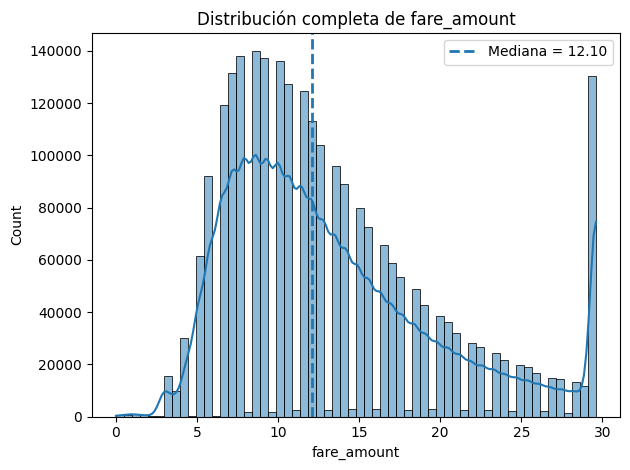

fare_amount - stats (sin nulos, con filtro de >0):
count   2567535.00
mean         13.48
std           6.65
min           0.01
50%          12.10
90%          24.00
95%          29.60
99%          29.60
max          29.60
Name: fare_amount, dtype: float64
Mediana: 12.1000
------------------------------------------------------------


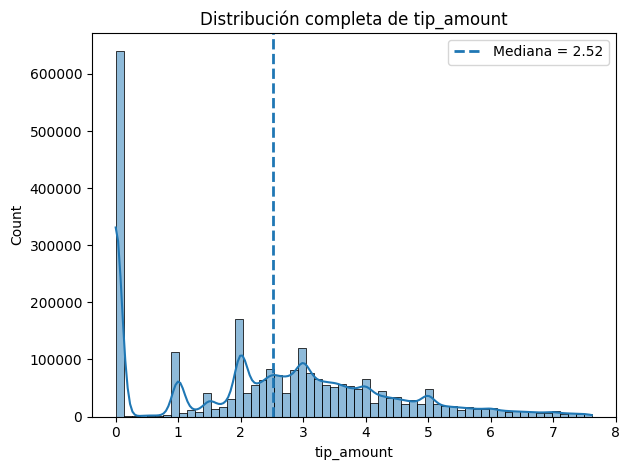

tip_amount - stats (sin nulos, con filtro de >0):
count   2567535.00
mean          2.45
std           1.87
min           0.00
50%           2.52
90%           5.00
95%           5.74
99%           7.00
max           7.62
Name: tip_amount, dtype: float64
Mediana: 2.5200
------------------------------------------------------------


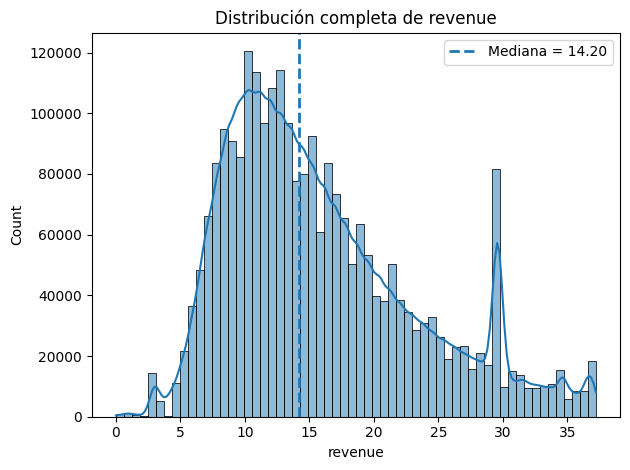

revenue - stats (sin nulos, con filtro de >0):
count   2567535.00
mean         15.92
std           7.41
min           0.01
50%          14.20
90%          27.80
95%          30.10
99%          36.11
max          37.22
Name: revenue, dtype: float64
Mediana: 14.2000
------------------------------------------------------------

===== Mapa: mediana de revenue por pickup_zone =====


C:\Users\pc\AppData\Local\Temp\ipykernel_27324\2775691052.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("pickup_zone")[revenue_col]


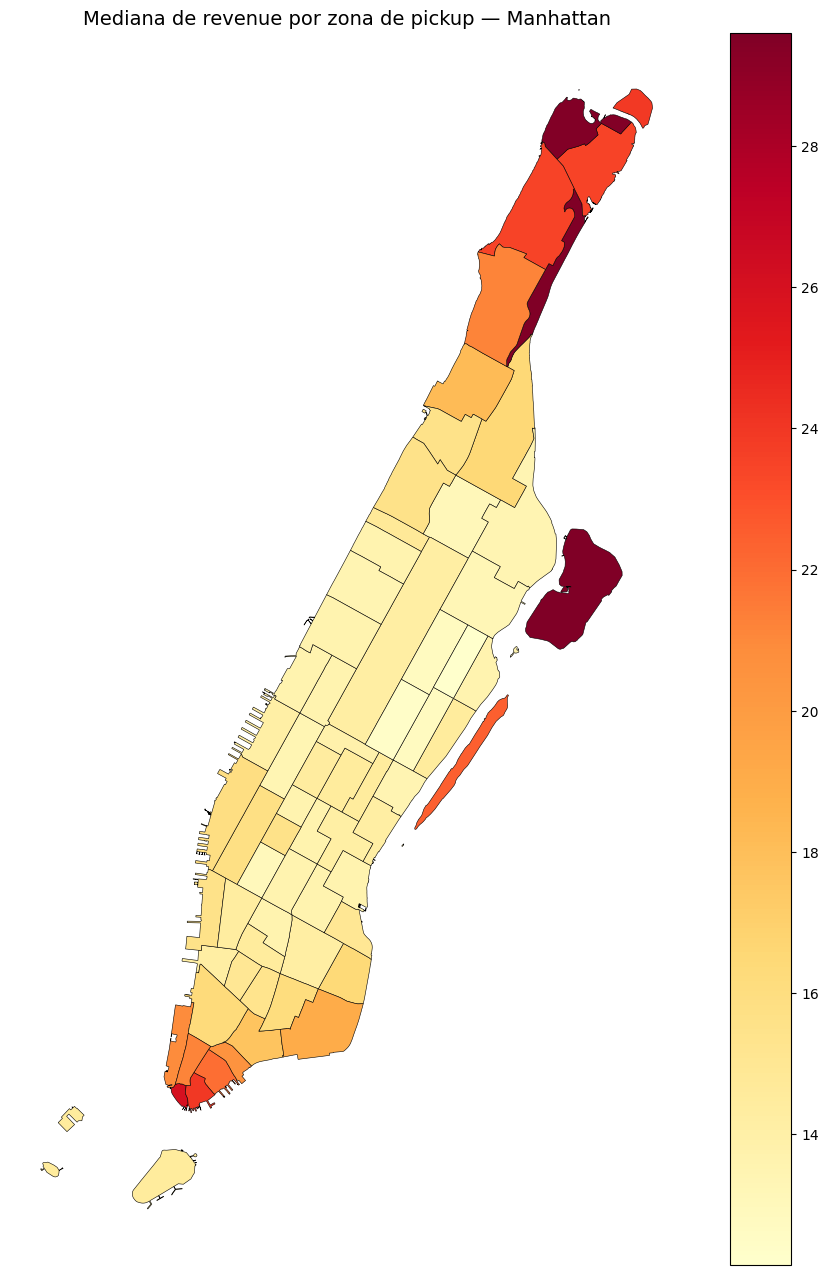


===== Heatmap: mediana de revenue por weekday × pickup_hr =====


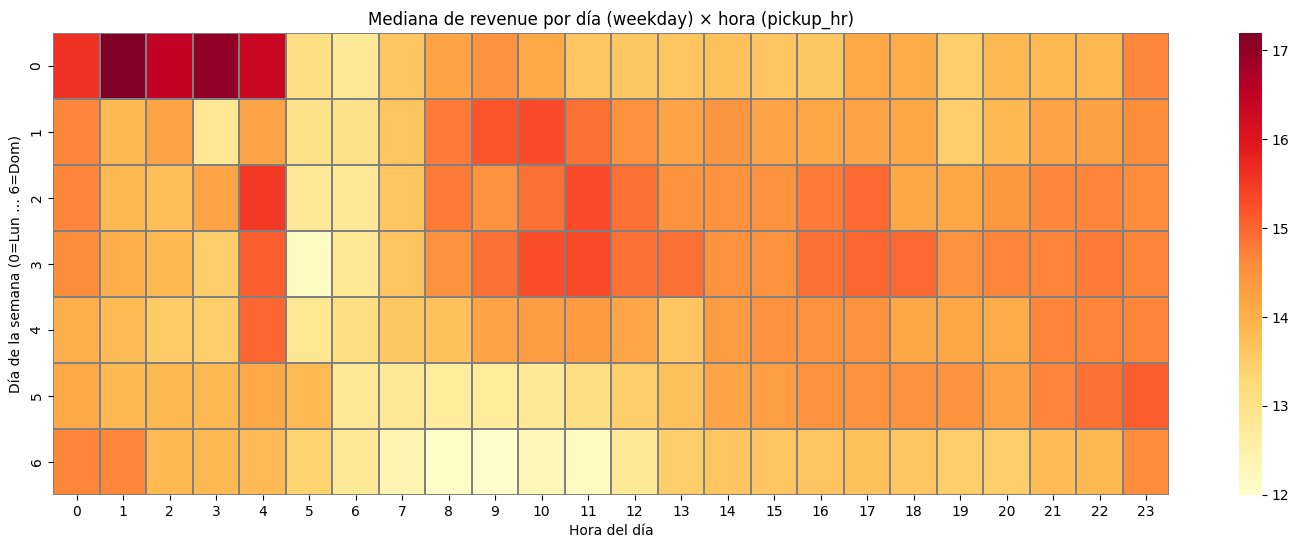

{'n_total_original': 2567535}

In [26]:
resumen_revenue = analisis_revenue(df_mh)
resumen_revenue


C:\Users\pc\AppData\Local\Temp\ipykernel_27324\3561060933.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col)


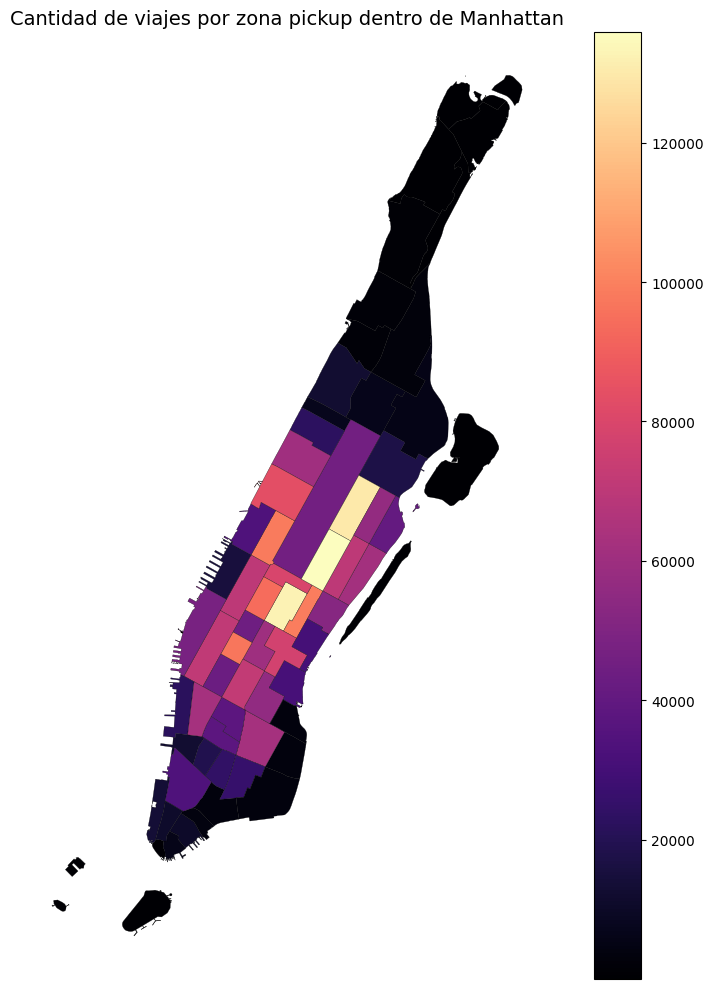

In [ ]:
mapa_heatmap_nyc(
    df_mh,
    group_col="pickup_zone",
    agg="count",
    title="Cantidad de viajes por zona pickup dentro de Manhattan",
    focus_borough="Manhattan"
)



===== Análisis temporal (Pickup) =====
Total registros: 2567535
No nulos (todas las columnas): 2567535 | Registros con algún nulo: 0

Día mínimo: 1 | Día máximo: 31
Horas presentes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] ...
Días de semana presentes (0=Lun … 6=Dom): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


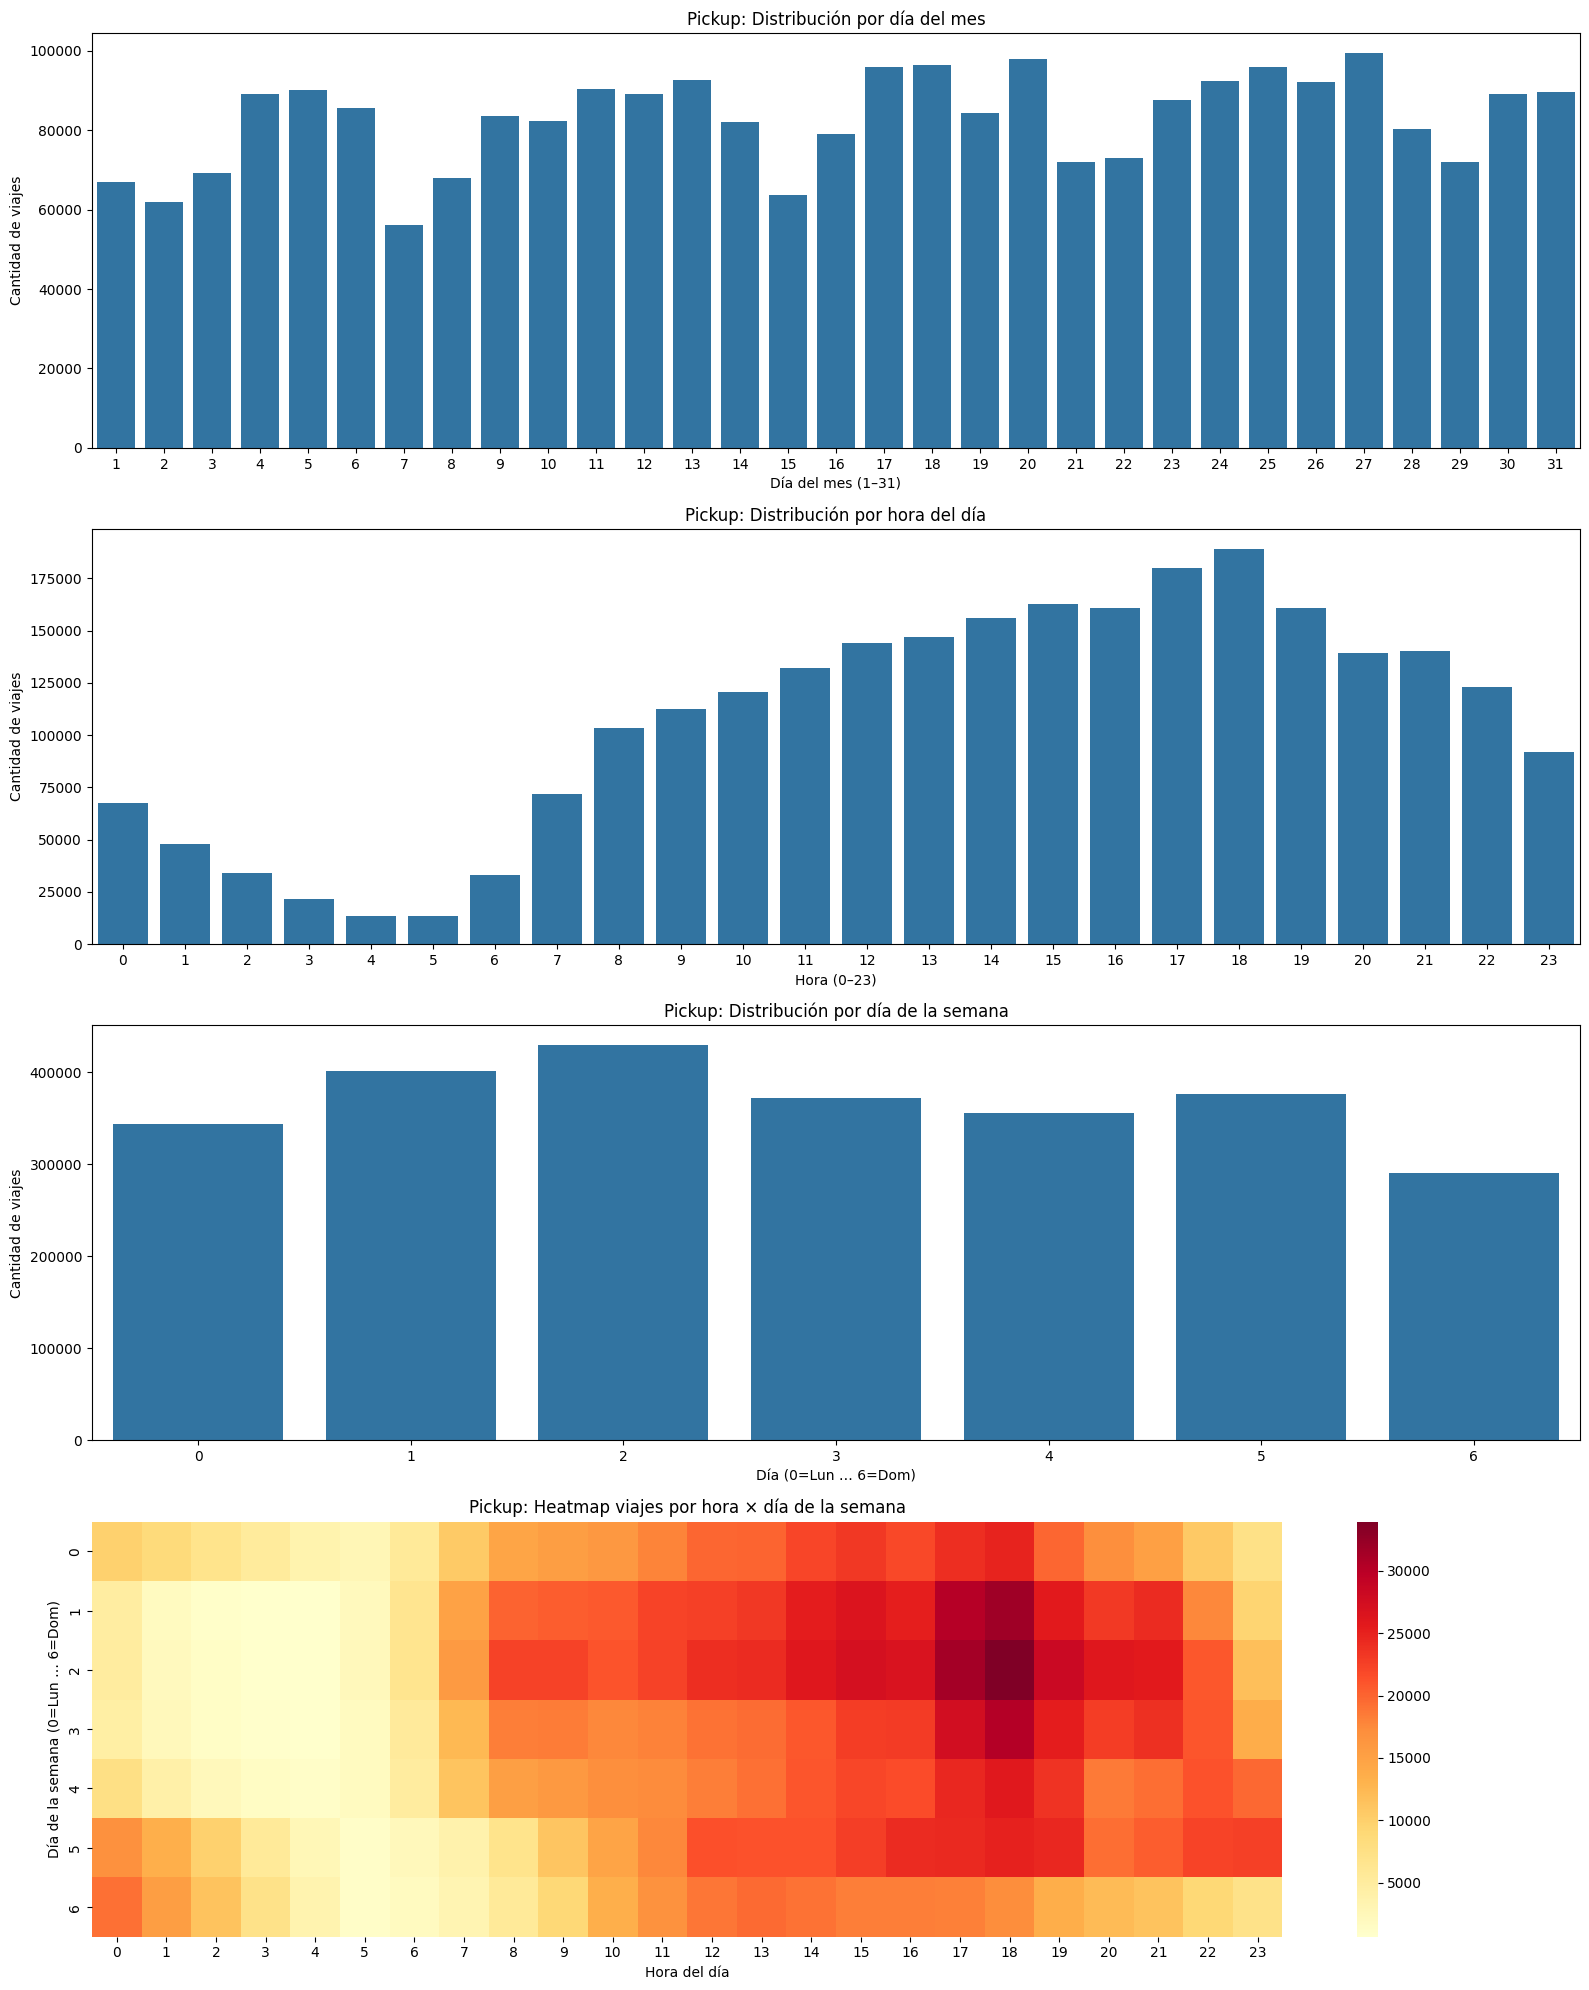

In [ ]:
resumen_pickup = resumen_temporal(
    df_mh,
    col_day="pickup_day",
    col_hour="pickup_hr",
    col_weekday="weekday",
    etiqueta="Pickup"
)



===== Análisis temporal (Dropoff) =====
Total registros: 2567535
No nulos (todas las columnas): 2567535 | Registros con algún nulo: 0

Día mínimo: 1 | Día máximo: 31
Horas presentes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] ...
Días de semana presentes (0=Lun … 6=Dom): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


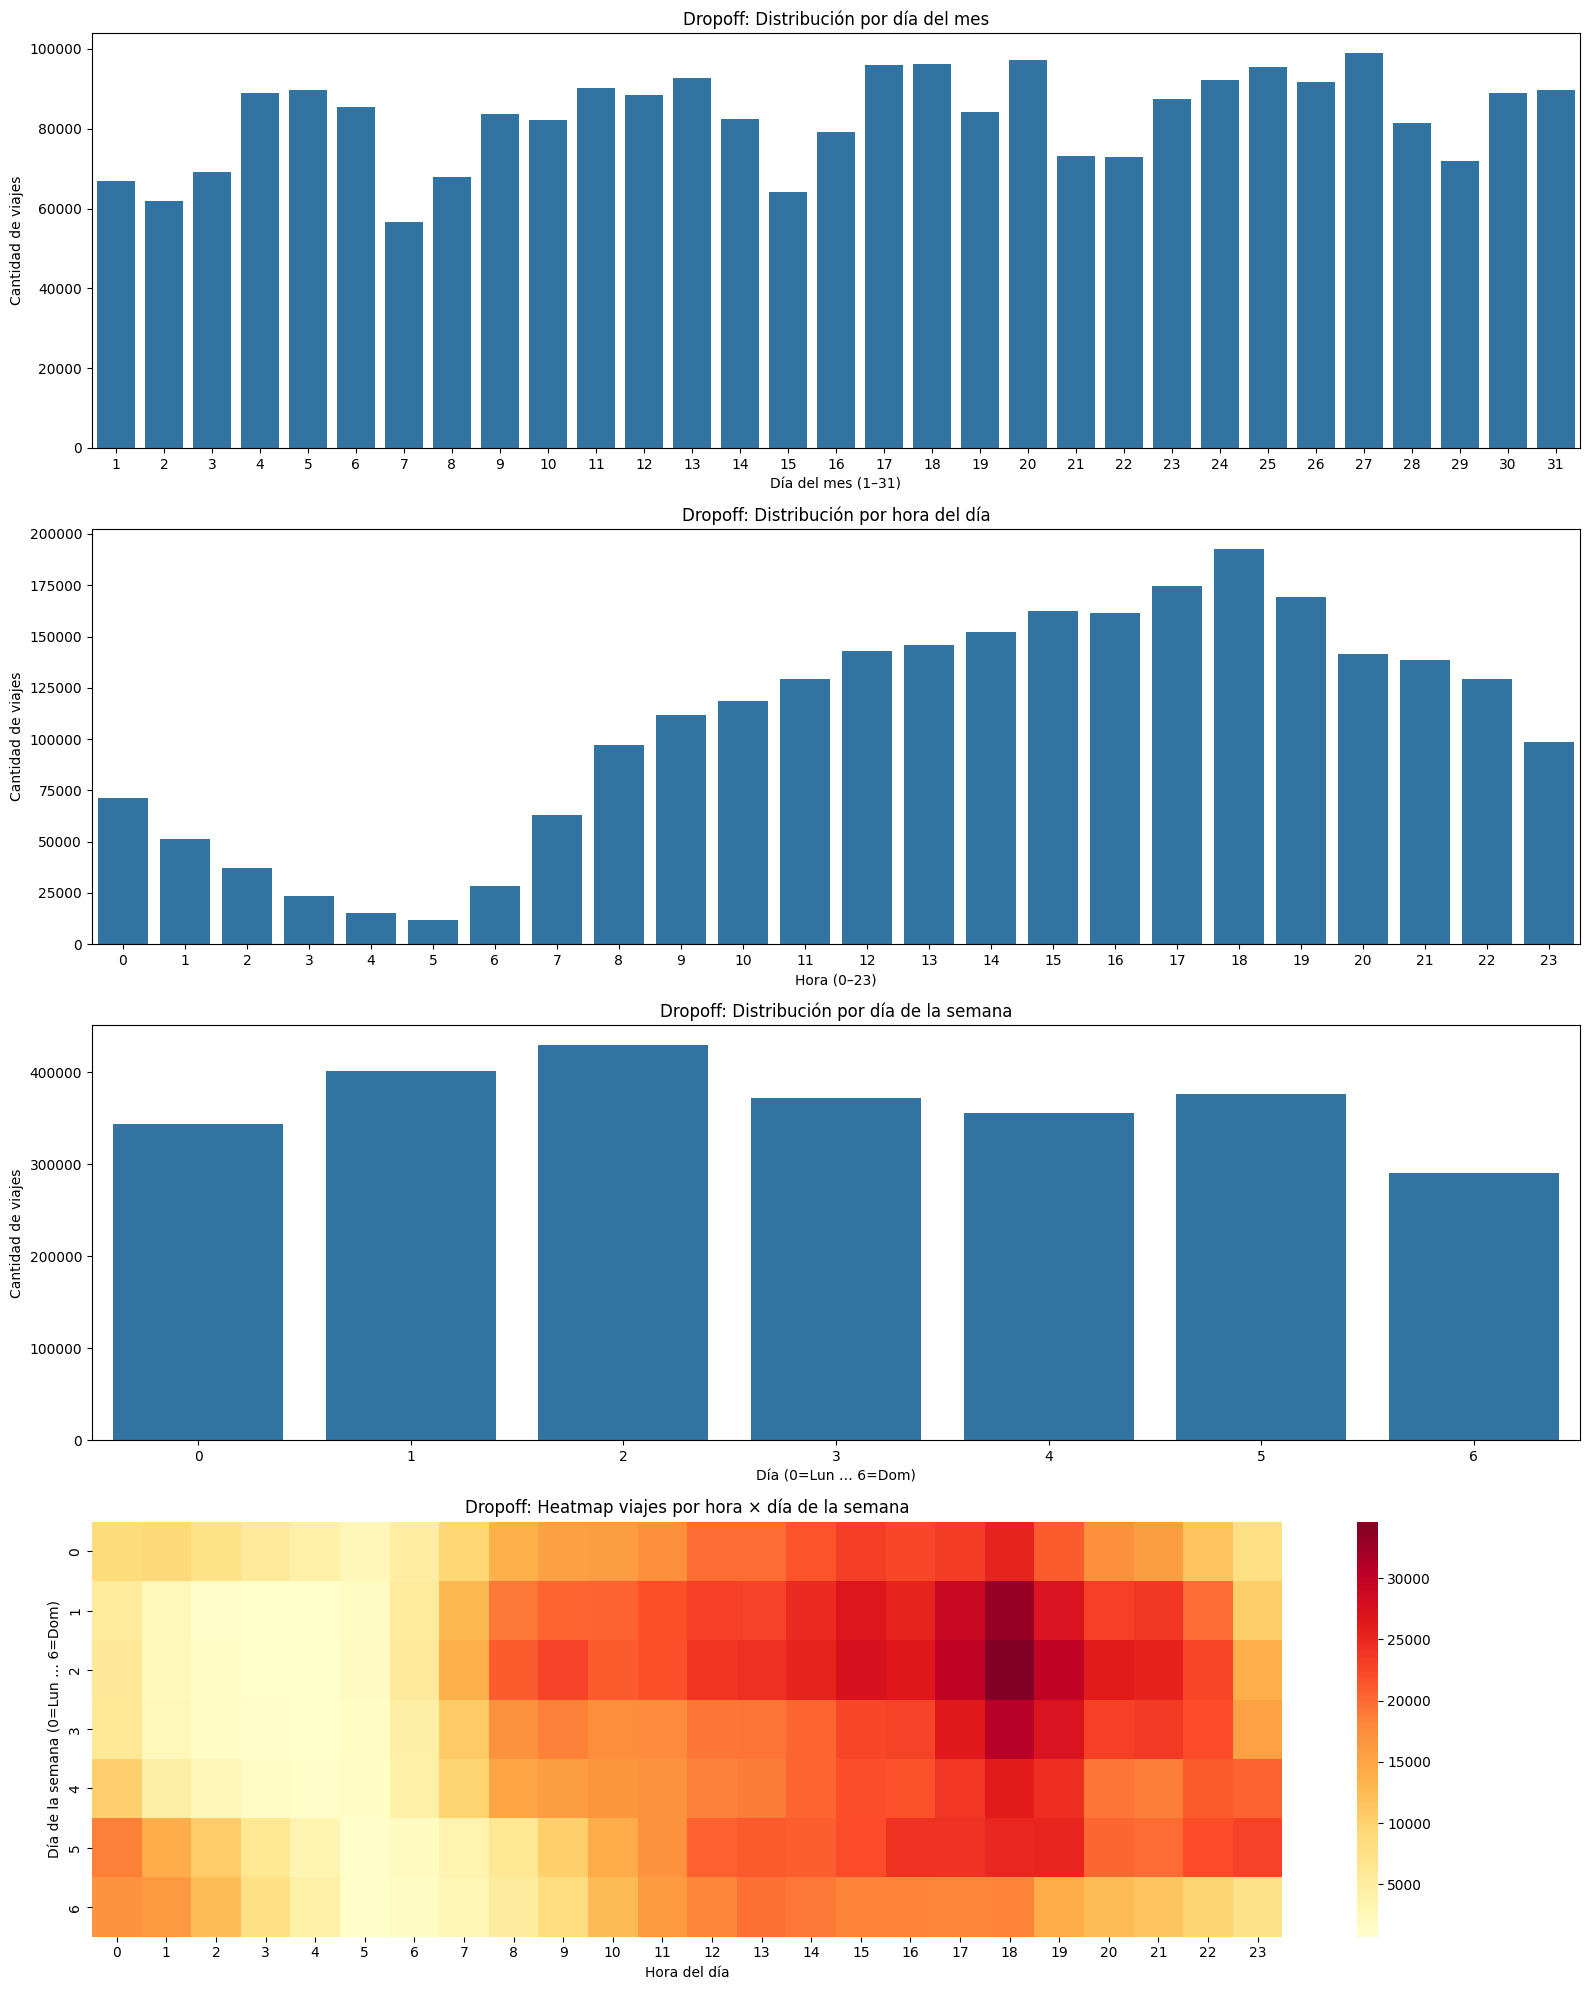

In [ ]:
resumen_pickup = resumen_temporal(
    df_mh,
    col_day="dropoff_day",
    col_hour="dropoff_hr",
    col_weekday="weekday",
    etiqueta="Dropoff"
)

In [27]:
# exportamos df limpio en formato parquet. para esto separamos por mes para no tener archivos muy grandes
# agregamos columna mes y separamos
df['month'] = df['tpep_pickup_datetime'].dt.month
for month, group in df.groupby('month'):
    group.drop(columns=['month'], inplace=True)
    group.to_parquet(f"../dataset/06-new-variables/yellow_tripdata_2024-{month:02d}.parquet", index=False)
